In [31]:
import scipy.stats as stats
import math
import numpy as np


## Standard Error (SE)

### For Mean

**Using Sample std** (unknown $\sigma$):
$$SE = \frac{s}{\sqrt{n}}$$

**Using Population std** (known $\sigma$):
$$SE = \frac{\sigma}{\sqrt{n}}$$

### For Proportion

$$SE = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

| Symbol | Meaning |
|---|---|
| $s$ | sample standard deviation |
| $\sigma$ | population standard deviation |
| $\hat{p}$ | sample proportion |
| $n$ | sample size |

## Margin of Error (ME)

### For Mean

**Using T** (small n (n =< 30) or unknown $\sigma$):
$$ME = t^* \cdot \frac{s}{\sqrt{n}}$$

**Using Z** (large n or known $\sigma$):
$$ME = z^* \cdot \frac{\sigma}{\sqrt{n}}$$

### For Proportion

$$ME = z^* \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

| Symbol | Meaning |
|---|---|
| $t^*$ | critical value from t-table with $df = n-1$ |
| $z^*$ | critical value from z-table |
| $s$ | sample standard deviation |
| $\sigma$ | population standard deviation |
| $\hat{p}$ | sample proportion |
| $n$ | sample size |

## Confidence Interval (CI)

### For Mean

**Using T** (small n (n<=30) or unknown $\sigma$):
$$CI = \bar{x} \pm t^* \cdot \frac{s}{\sqrt{n}}$$

**Using Z** (large n or known $\sigma$):
$$CI = \bar{x} \pm z^* \cdot \frac{\sigma}{\sqrt{n}}$$

### For Proportion

$$CI = \hat{p} \pm z^* \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$
### the proportion we calculate:
$$\hat{p} = \frac{x}{n}$$
| Symbol | Meaning |
|---|---|
| $\bar{x}$ | sample mean |
| $\hat{p}$ | sample proportion |
| $t^*$ | critical value from t-table with $df = n-1$ |
| $z^*$ | critical value from z-table |
| $s$ | sample standard deviation |
| $\sigma$ | population standard deviation |
| $n$ | sample size |

### Key Insight

$$CI = \bar{x} \pm ME \quad \text{(for mean)}$$
$$CI = \hat{p} \pm ME \quad \text{(for proportion)}$$

$$\text{wider CI} \rightarrow \text{more confident} \rightarrow \text{less precise}$$
$$\text{narrower CI} \rightarrow \text{less confident} \rightarrow \text{more precise}$$
*CI is always two tailed*

## Finding Critical Values

### Z Critical ($z^*$)
CL stands for Confidence Level
$$\text{lookup} = \frac{1+CL}{2}$$

Then find $z^*$ where $P(Z \leq z^*) = \text{lookup}$ <br>
(using the z table)

| CL | lookup | $z^*$ |
|---|---|---|
| 90% | 0.95 | 1.645 |
| 95% | 0.975 | 1.96 |
| 98% | 0.99 | 2.33 |
| 99% | 0.995 | 2.575 |

---

### T Critical ($t^*$)

$$df = n - 1$$

$$\text{lookup} = \frac{1+CL}{2}$$

Then find $t^*$ in t-table at row $df$ and column $\text{lookup}$<br> (using the t table)

| CL | lookup | $df$ | $t^*$ |
|---|---|---|---|
| 95% | 0.975 | 9 | 2.262 |
| 95% | 0.975 | 19 | 2.093 |
| 95% | 0.975 | 29 | 2.045 |
| 95% | 0.975 | $\infty$ | 1.96 |

---

### Z vs T

| Condition | Use |
|---|---|
| large $n$ or known $\sigma$ | $z^*$ |
| small $n$ or unknown $\sigma$ | $t^*$ with $df = n-1$ |

$$t^* \xrightarrow{df \to \infty} z^*$$

In [4]:
#  for mean using the z critical
# The average test scores in the physics class is normally distributed with a standard deviation of 5.4. 50 scores with a sample mean of 79 were selected at random. Find a 95% confidence interval of the population mean test scores.


# Specify sample mean (x_bar), sample standard deviation (s), sample size (n) and confidence level
x_bar = 79
s = 5.4
n = 50
confidence_level = 0.95
# area to the left = P(z_critical)
p_value_of_z_critical = (confidence_level + 1) / 2

# calculating the critical z, standard error and margin of error
z_critical = stats.norm.ppf(p_value_of_z_critical)
standard_error = s / math.sqrt(n)
margin_of_error = z_critical * standard_error

# Calculate the lower and upper bound of the confidence interval
lower_bound = x_bar - margin_of_error
upper_bound = x_bar + margin_of_error

# Print the results
print(f"Critical z-value: {z_critical:.3f}")
print(f"Margin of Error: {margin_of_error:.3f}")
print(f"Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Conclusion: We are  {confidence_level:.1%} confidence  for that the population mean is:")
print(f"between {lower_bound:.3f} and {upper_bound:.3f}")

Critical z-value: 1.960
Margin of Error: 1.497
Confidence Interval: [77.503, 80.497]
Conclusion: We are  95.0% confidence  for that the population mean is:
between 77.503 and 80.497


In [5]:
# for mean using t critical
# The average weight of 20 students in a certain school was found to tbe 165 lbs with a standard deviation of 4.5. construct a 95% confidence interval for the population mean.

# Specify sample mean (x_bar), sample standard deviation (s), sample size (n) and confidence level
x_bar = 165
s = 4.5
n = 20
confidence_level = 0.95

# area to the left = P(z_critical
p_value_of_t_critical = (confidence_level + 1) / 2

# Calculate degrees of freedom (df), the critical t-value, and the margin of error
df = n - 1
t_critical = stats.t.ppf(p_value_of_t_critical, df)
standard_error = s / math.sqrt(n)
margin_of_error = t_critical * standard_error

# Calculate the lower and upper bound of the confidence interval
lower_bound = x_bar - margin_of_error
upper_bound = x_bar + margin_of_error

# Print the results
print(f"Critical t-value: {t_critical:.3f}")
print(f"Margin of Error: {margin_of_error:.3f}")
print(f"Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Conclusion: We are  {confidence_level:.1%} confidence  for that the population mean is:")
print(f"between {lower_bound:.3f} and {upper_bound:.3f}")

Critical t-value: 2.093
Margin of Error: 2.106
Confidence Interval: [162.894, 167.106]
Conclusion: We are  95.0% confidence  for that the population mean is:
between 162.894 and 167.106


In [6]:
# for proportion
# 584 out of 800 randomly selected college students at university XYZ responded yes to owning a laptop. Construct a 95% confidence interval to estimate the true population proportion of students who own laptops and determine the margin of error.

# Specify sample occurrences (x), sample size (n) and confidence level
x = 584
n = 800
confidence_level = 0.95
# area to the left = P(z_critical)
p_value_of_z_critical = (confidence_level + 1) / 2

# calculating the sample proportion p_hat, critical z, standard error and margin of error
p_hat = x / n
z_critical = stats.norm.ppf(p_value_of_z_critical)
standard_error = math.sqrt((p_hat*(1-p_hat)/n))
margin_of_error = z_critical * standard_error

# Calculate the lower and upper bound of the confidence interval
lower_bound = p_hat - margin_of_error
upper_bound = p_hat + margin_of_error

# Print the results
print(f"Critical z-value: {t_critical:.3f}")
print(f"Margin of Error: {margin_of_error:.3f}")
print(f"Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Conclusion: We are  {confidence_level:.1%} confidence  for that the population proportion is:")
print(f"between {lower_bound:.3f} and {upper_bound:.3f}")

print("Final Answer: We are 95% confident that the true proportion of all students at the university who own laptops is between 0.6992 and 0.7608 (or 69.92% to 76.08%).")

Critical z-value: 2.093
Margin of Error: 0.031
Confidence Interval: [0.699, 0.761]
Conclusion: We are  95.0% confidence  for that the population proportion is:
between 0.699 and 0.761
Final Answer: We are 95% confident that the true proportion of all students at the university who own laptops is between 0.6992 and 0.7608 (or 69.92% to 76.08%).


## Sample Size (n)

the logic is:

"how many samples do I need to be 95% confident within ±E of the true mean?"

The goal is to find the **minimum sample size** needed given:
- Confidence Level (→ gives you $z^*$)
- Margin of Error ($E$)
- Standard deviation ($\sigma$) or population proportion ($\hat{p}$)

---

### Case 1: For Mean (standard deviation is given)

$$n = \left(\frac{z^* \cdot \sigma}{E}\right)^2$$

| Symbol | Meaning |
|---|---|
| $z^*$ | critical value from z-table at given CL |
| $\sigma$ | population standard deviation |
| $E$ | margin of error |

---

### Case 2: For Proportion (no standard deviation given)

$$n = \frac{z^{*2} \cdot \hat{p}(1-\hat{p})}{E^2}$$

| Symbol | Meaning |
|---|---|
| $z^*$ | critical value from z-table at given CL |
| $\hat{p}$ | estimated population proportion (use $0.5$ if unknown) |
| $E$ | margin of error in decimal (e.g., $5\% \rightarrow 0.05$) |

> If $\hat{p}$ is unknown, use $\hat{p} = 0.5$ — this gives the **maximum sample size**

---

### Common $z^*$ Values

| Confidence Level | $z^*$ |
|---|---|
| 90% | 1.645 |
| 95% | 1.96 |
| 98% | 2.33 |
| 99% | 2.575 |

In [7]:
# The average test score of all students in a certain class was 84 with a standard deviation of 15. If the margin of error was calculated to be 5.367 at a 95% confidence level, how many students were in this class?

# Specify population standard deviation (sigma), margin of error (margin_of_error) and confidence level

sigma = 15
margin_of_error = 5.367
confidence_level = 0.95

# calculating the critical z value
# area to the left = P(z_critical)
p_value_of_z_critical = (confidence_level + 1) / 2
z_critical = stats.norm.ppf(p_value_of_z_critical)

# calculating sample size
n = math.pow(((z_critical * sigma) / margin_of_error), 2)
print(f"We need at least {math.ceil(n)} students in the sample.")

We need at least 31 students in the sample.


In [8]:
# Sally wants to determine what proportion of high school students are planning to enroll in college after they graduate. Given a 95% confidence level and a margin of error of 5%, what is the maximum sample size needed for this statistical experiment?

# Specify confidence level, margin of error and sample proportion
confidence_level = 0.95
margin_of_error = 0.05
# since proportion is unknown, we use 0.5 based on maximum variability rule
p_hat = 0.5

# calculating the critical z value
# area to the left = P(z_critical)
p_value_of_z_critical = (confidence_level + 1) / 2
z_critical = stats.norm.ppf(p_value_of_z_critical)

# # calculating sample size
n = (math.pow(z_critical, 2) * p_hat * (1 - p_hat)) / math.pow(margin_of_error, 2)
print(f"We need at least {math.ceil(n)} students in the sample.")



We need at least 385 students in the sample.


# Hypothesis Testing

**Null Hypothesis ($H_0$):** the claim being tested (assumed true).
**Alternative Hypothesis ($H_1$):** what we want to prove.

**Decision Rule (p-value method):**
$$p < \alpha \rightarrow \text{reject } H_0$$
$$p \geq \alpha \rightarrow \text{fail to reject } H_0$$

| Symbol | Meaning |
|---|---|
| $H_0$ | null hypothesis (the claim) |
| $H_1$ | alternative hypothesis |
| $\alpha$ | significance level $= 1 - CL$ |
| $p$ | p-value (probability of result by chance) |

---

## Z Test (large n or known $\sigma$)

**Test Statistic:**
$$z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

| Symbol | Meaning |
|---|---|
| $\bar{x}$ | sample mean |
| $\mu_0$ | claimed population mean (from $H_0$) |
| $\sigma$ | population standard deviation |
| $n$ | sample size |

### Left Tail
$$H_1: \mu < \mu_0$$
$$p = P(Z \leq z)$$

### Right Tail
$$H_1: \mu > \mu_0$$
$$p = 1 - P(Z \leq z)$$

### Two Tail
$$H_1: \mu \neq \mu_0$$
$$p = 2 \cdot (1 - P(Z \leq |z|))$$

---

## T Test (small n or unknown $\sigma$)

**Test Statistic:**
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \quad df = n - 1$$

| Symbol | Meaning |
|---|---|
| $\bar{x}$ | sample mean |
| $\mu_0$ | claimed population mean (from $H_0$) |
| $s$ | sample standard deviation |
| $n$ | sample size |
| $df$ | degrees of freedom $= n - 1$ |

### Left Tail
$$H_1: \mu < \mu_0$$
$$p = P(T \leq t)$$

### Right Tail
$$H_1: \mu > \mu_0$$
$$p = 1 - P(T \leq t)$$

### Two Tail
$$H_1: \mu \neq \mu_0$$
$$p = 2 \cdot (1 - P(T \leq |t|))$$

---

## Proportion Test (always Z)

**Test Statistic:**
$$z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}$$

**Condition:** $np_0 \geq 5$ and $n(1-p_0) \geq 5$

| Symbol | Meaning                                    |
|---|--------------------------------------------|
| $\hat{p}$ | sample proportion                          |
| $p_0$ | claimed population proportion (from $H_0$) |
| $n$ | sample size                                |

### Left Tail
$$H_1: p < p_0$$
$$p = P(Z \leq z)$$

### Right Tail
$$H_1: p > p_0$$
$$p = 1 - P(Z \leq z)$$

### Two Tail
$$H_1: p \neq p_0$$
$$p = 2 \cdot (1 - P(Z \leq |z|))$$

---

## Summary

| Test | Statistic | When |
|---|---|---|
| Z | $\frac{\bar{x} - \mu_0}{\sigma/\sqrt{n}}$ | large n or known $\sigma$ |
| T | $\frac{\bar{x} - \mu_0}{s/\sqrt{n}}$ | small n or unknown $\sigma$ |
| Proportion | $\frac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}}$ | always Z |

| Tail | $H_1$ | p-value |
|---|---|---|
| Left | $<$ | $P(\leq \text{stat})$ |
| Right | $>$ | $1 - P(\leq \text{stat})$ |
| Two | $\neq$ | $2 \cdot (1 - P(\leq \mid\text{stat}\mid))$ |


*left tail*<br>
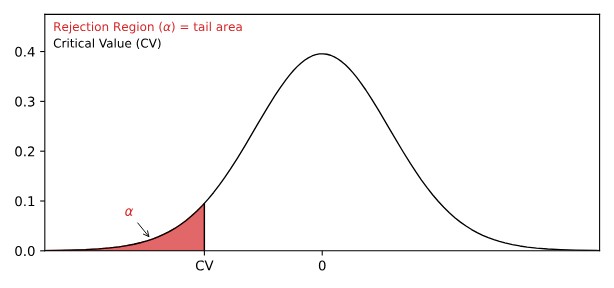

*right tail*<br>
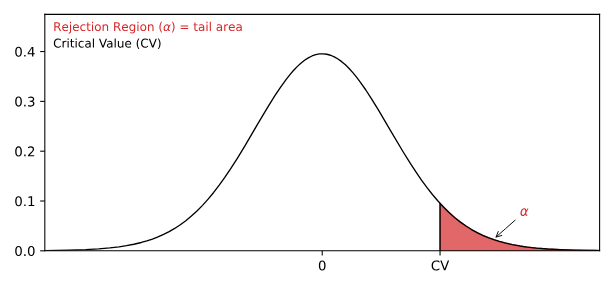

*two tail*<br>
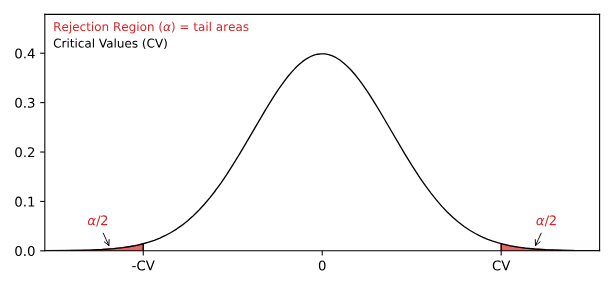

## When to Use Z vs T (Real-World Practice)

### Decision Rule

$$\sigma \text{ known} \rightarrow \text{use Z}$$
$$\sigma \text{ unknown} \rightarrow \text{use T (any sample size)}$$

> In practice $\sigma$ is **almost always unknown**, so **T is the default** for means.

---

### Summary Table

| Population SD ($\sigma$) | Distribution |
|---|---|
| known | **Z** |
| unknown | **T** (any $n$) |

---

### Why T even for large n?

$$t(df \geq 30) \approx z \quad \leftarrow \text{nearly identical anyway}$$

So using T is never wrong — it just converges to Z as $n$ grows. There's no downside to always using T when $\sigma$ is unknown.

---

### For Proportions

$$\text{always use Z}$$

**Condition:** $np \geq 5$ and $n(1-p) \geq 5$

## Confidence Level (CL) and Significance Level (SL)

$$\alpha = 1 - CL \quad \text{(Significance Level)}$$

### One-Tailed Left

$$\alpha = 1 - CL$$

$$\text{lookup} = CL$$

$$\underbrace{\alpha}_{\text{left tail}} \quad | \quad \overbrace{\quad CL \quad}^{\text{right area}}$$

### One-Tailed Right

$$\alpha = 1 - CL$$

$$\text{lookup} = 1 - \alpha = CL$$

$$\overbrace{\quad CL \quad}^{\text{left area}} \quad | \quad \underbrace{\alpha}_{\text{right tail}}$$

### Two-Tailed

$$\alpha = 1 - CL$$

$$\text{each tail} = \frac{\alpha}{2} = \frac{1 - CL}{2}$$

$$\text{lookup} = 1 - \frac{\alpha}{2} = \frac{1 + CL}{2}$$

$$\underbrace{\frac{\alpha}{2}}_{\text{left tail}} \quad \overbrace{\quad CL \quad}^{\text{CI}} \quad \underbrace{\frac{\alpha}{2}}_{\text{right tail}}$$

| Situation | Each Tail        | Lookup           |
|---|------------------|------------------|
| One-tailed left | $\alpha$         | $1 - CL$         |
| One-tailed right | $1 - \alpha$     | $CL$             |
| Two-tailed | $1- \frac{\alpha}{2}$ | $\frac{1+CL}{2}$ |

**confidence level for z test**
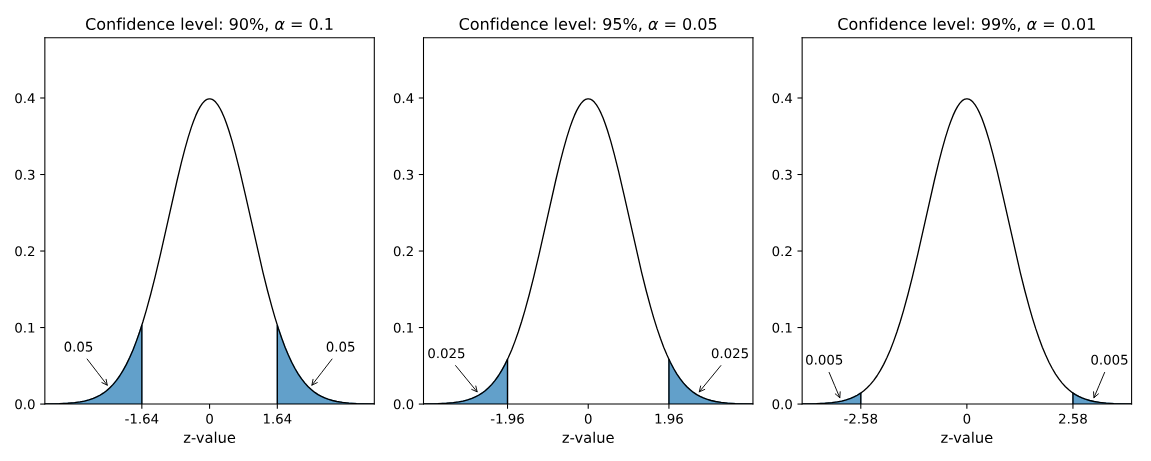

**confidence level for t test**
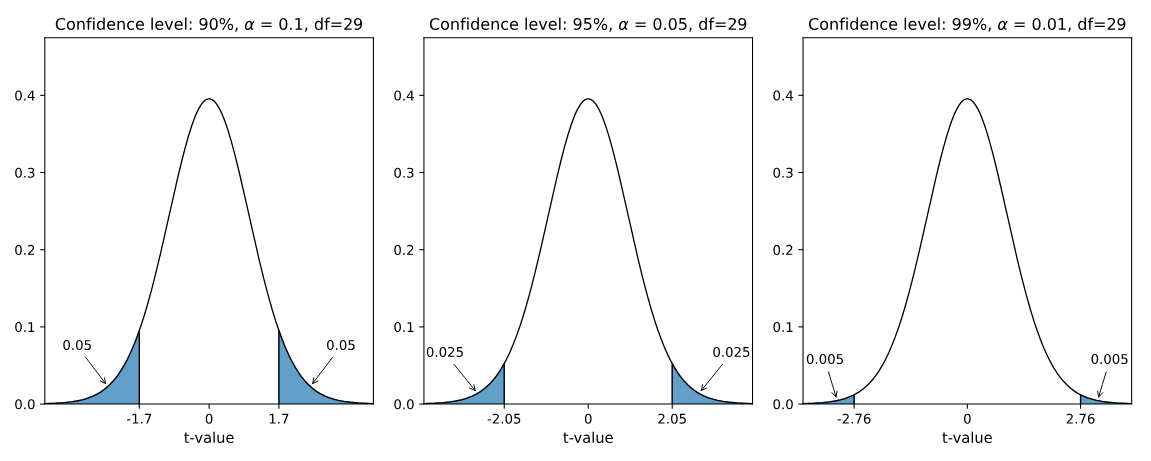

### z-test questions

In [9]:
"""
The average weight of all residents in town XYZ is 168 lbs. A nutritionist believes the true mean is different. She measured the weight of 36 individuals and found the mean to be 169.5 lbs with a known population standard deviation of 3.9. State the null and alternative hypotheses. At a 95% confidence level, is there enough evidence to discard the null hypothesis?

H0: mu == 168
H1: MU != 168 -> two tail

known population standard deviation (sigma) --> z-test
"""
# Specify the sample size (n), sample mean (x_bar), population standard deviation (sigma), population mean (mu_0), confidence level, and Significance level (alpha)
mu_0 = 168
x_bar = 169.5
sigma = 3.9
n = 36

# calculate alpha
confidence_level = 0.95
alpha = 1 - confidence_level

# calculating the z_critical
z_critical = stats.norm.ppf(1 - alpha / 2)

# calculating the z statistic using the z test
z_statistic = (x_bar - mu_0) / (sigma / math.sqrt(n))

print("=== Critical Value Method ===")
print(f"z statistic = {z_statistic:.4f}")
print(f"z critical  = ±{z_critical:.4f}")

if abs(z_statistic) > z_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# two-tailed
p_value = 2 * (1 - stats.norm.cdf(abs(z_statistic)))

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

print("Conclusion: Yes, there is enough evidence to discard the null hypothesis. The true mean weight is significantly different from 168 lbs.")

=== Critical Value Method ===
z statistic = 2.3077
z critical  = ±1.9600
Reject H0

=== P-value Method ===
p-value = 0.021016
alpha   = 0.050000000000000044
Reject H0
Conclusion: Yes, there is enough evidence to discard the null hypothesis. The true mean weight is significantly different from 168 lbs.


In [10]:
"""
A factory manufactures cars with a 5-year warranty on the engine and transmission. An engineer believes the engine or transmission will malfunction in less than 5 years. He tests a sample of 40 cars and finds the average time to be 4.8 years. population standard deviation is 0.50. (a) State the null and alternative hypotheses. (b) At a 2% significance level, is there enough evidence to support the idea that the warranty should be revised?

H0: mu >=  5
H1: mu < 5 -> left tail

known population standard deviation (sigma) --> z-test
"""
# Specify the sample size (n), sample mean (x_bar), population standard deviation (sigma), population mean (mu_0), confidence level, and Significance level (alpha)
mu_0 = 5
x_bar = 4.8
sigma = 0.5
n = 40
alpha = 0.02

# calculating the z_critical
z_critical = stats.norm.ppf(alpha)

# calculating the z statistic using the z test
z_statistic = (x_bar - mu_0) / (sigma / math.sqrt(n))

print("=== Critical Value Method ===")
print(f"z statistic = {z_statistic:.4f}")
print(f"z critical  = {z_critical:.4f}")

if z_statistic < z_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# left tail
p_value = stats.norm.cdf(z_statistic)

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

print("Conclusion: Yes,  there is enough evidence to support that the warranty should be revised. The average malfunction time is significantly less than 5 years.")


=== Critical Value Method ===
z statistic = -2.5298
z critical  = -2.0537
Reject H0

=== P-value Method ===
p-value = 0.005706
alpha   = 0.02
Reject H0
Conclusion: Yes,  there is enough evidence to support that the warranty should be revised. The average malfunction time is significantly less than 5 years.


In [11]:
"""
A coffee machine is designed to dispense an average of 350 mL per cup. A manager suspects the machine is overfilling (dispensing more than 350 mL). She tests 45 cups and finds the average to be 352 mL. The population standard deviation is known to be 12 mL. (a) State the null and alternative hypotheses. (b) At a 5% significance level, is there enough evidence to support that the machine is overfilling?
H0: mu <=  350
H1: mu > 350 -> right tail

known population standard deviation (sigma) --> z-test
"""
# Specify the sample size (n), sample mean (x_bar), population standard deviation (sigma), population mean (mu_0), confidence level, and Significance level (alpha)
mu_0 = 350
x_bar = 352
sigma = 12
n = 45
alpha = 0.05

# calculating the z_critical
z_critical = stats.norm.ppf(1 - alpha)

# calculating the z statistic using the z test
z_statistic = (x_bar - mu_0) / (sigma / math.sqrt(n))

print("=== Critical Value Method ===")
print(f"z statistic = {z_statistic:.4f}")
print(f"z critical  = {z_critical:.4f}")


if z_statistic > z_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# right tail
p_value = 1 - stats.norm.cdf(z_statistic)

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


print("Conclusion: No, there is not enough evidence to support that the machine is overfilling. The average amount dispensed (352 mL) is not significantly more than 350 mL.")

=== Critical Value Method ===
z statistic = 1.1180
z critical  = 1.6449
Fail to reject H0

=== P-value Method ===
p-value = 0.131776
alpha   = 0.05
Fail to reject H0
Conclusion: No, there is not enough evidence to support that the machine is overfilling. The average amount dispensed (352 mL) is not significantly more than 350 mL.


### t-test questions

In [12]:
"""
A factory has a machine that dispenses 80 mL of fluid into a bottle. An employee believes the average amount of fluid is not 80 mL. Using 40 samples, he measures the average amount dispensed to be 78 mL with a standard deviation of 2.5.  State the null and alternative hypotheses. At a 95% confidence level, is there enough evidence to support the idea that the machine is not working properly?

H0: mu == 80
H1: mu != 80 --> two tail

unknown population standard deviation (sigma) --> t-test

"""

# Specify the sample size (n), sample mean (x_bar), sample standard deviation (s), population mean (mu_0), confidence level, and Significance level (alpha), degree of freedom (df)
n = 40
x_bar = 78
s = 2.5
mu_0 = 80
df = n - 1
# calculate alpha
confidence_level = 0.95
alpha = 1 - confidence_level

# calculating t_critical
t_critical = stats.t.ppf(1 - alpha / 2, df)

# calculating the t statistic using the t test
t_statistic = (x_bar - mu_0) / (s / math.sqrt(n))

print("=== Critical Value Method ===")
print(f"t statistic = {t_statistic:.4f}")
print(f"t critical  = ±{t_critical:.4f}")

if abs(t_statistic) > t_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# two-tailed
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")
print("Conclusion: Yes, there is enough evidence to support that the machine is not working properly. The average amount of fluid dispensed (78 mL) is significantly different from the claimed 80 mL.")

=== Critical Value Method ===
t statistic = -5.0596
t critical  = ±2.0227
Reject H0

=== P-value Method ===
p-value = 0.000010
alpha   = 0.050000000000000044
Reject H0
Conclusion: Yes, there is enough evidence to support that the machine is not working properly. The average amount of fluid dispensed (78 mL) is significantly different from the claimed 80 mL.


In [13]:
"""
A company manufactures car batteries with an average life span of 2 or more years. An engineer believes this value to be less. Using 10 samples, he measures the average life span to be 1.8 years with a standard deviation of 0.15.
(a) State the null and alternative hypotheses.
(b) At a 99% confidence level, is there enough evidence to discard the null hypothesis?

H0: mu >=  2
H1: mu < 2 -> left tail

unknown population standard deviation (sigma) --> t-test
"""
# Specify the sample size (n), sample mean (x_bar), sample standard deviation (s), population mean (mu_0), confidence level, and Significance level (alpha), degree of freedom (df)
n = 10
x_bar = 1.8
s = 0.15
mu_0 = 2
df = n - 1
# calculate alpha
confidence_level = 0.99
alpha = 1 - confidence_level

# calculating t_critical
t_critical = stats.t.ppf(alpha, df)

# calculating the t statistic using the t test
t_statistic = (x_bar - mu_0) / (s / math.sqrt(n))

print("=== Critical Value Method ===")
print(f"t statistic = {t_statistic:.4f}")
print(f"t critical  = {t_critical:.4f}")

if t_statistic < t_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# left-tailed
p_value =  stats.t.cdf(t_statistic, df)

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

print("Conclusion: Yes, there is enough evidence to discard the null hypothesis. The average battery life span is significantly less than 2 years.")

=== Critical Value Method ===
t statistic = -4.2164
t critical  = -2.8214
Reject H0

=== P-value Method ===
p-value = 0.001126
alpha   = 0.010000000000000009
Reject H0
Conclusion: Yes, there is enough evidence to discard the null hypothesis. The average battery life span is significantly less than 2 years.


In [14]:
"""
A gym claims its members lose an average of 5 or more kg after completing their 8-week program. A researcher believes the actual weight loss is higher. A sample of 15 members shows an average weight loss of 5.3 kg with a standard deviation of 1.2 kg. At a 95% confidence level, is there enough evidence to support the researcher's claim?

H0: mu <=  5
H1: mu > 5 -> right tail

unknown population standard deviation (sigma) --> t-test
"""
# Specify the sample size (n), sample mean (x_bar), sample standard deviation (s), population mean (mu_0), confidence level, and Significance level (alpha), degree of freedom (df)
n = 15
x_bar = 5.3
s = 1.2
mu_0 = 5
df = n - 1
# calculate alpha
confidence_level = 0.95
alpha = 1 - confidence_level

# calculating t_critical
t_critical = stats.t.ppf(1 - alpha, df)

# calculating the t statistic using the t test
t_statistic = (x_bar - mu_0) / (s / math.sqrt(n))

print("=== Critical Value Method ===")
print(f"t statistic = {t_statistic:.4f}")
print(f"t critical  = {t_critical:.4f}")

if t_statistic > t_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# right tail
p_value = 1 - stats.t.cdf(t_statistic, df)

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

print("Conclusion: No, there is not enough evidence to support the researcher's claim. The average weight loss is not significantly higher than 5 kg.")

=== Critical Value Method ===
t statistic = 0.9682
t critical  = 1.7613
Fail to reject H0

=== P-value Method ===
p-value = 0.174676
alpha   = 0.050000000000000044
Fail to reject H0
Conclusion: No, there is not enough evidence to support the researcher's claim. The average weight loss is not significantly higher than 5 kg.


### proportion questions

In [15]:
"""
A tech company believes that the percentage of residents in town XYZ that own a cell phone is 70%. A marketing manager believes this value to be different. He conducts a survey of 200 individuals and found that 130 responded yes to owning a cell phone.
(a) State the null and alternative hypotheses.
(b) At a 95% confidence level, is there enough evidence to reject the null hypothesis?
H0: p == 0.70
H1: p != 0.70 --> two tail
"""

# Specify the sample size (n), success numbers (x), sample proportion (p_hat), population proportion (p0)
n = 200
x = 130
p0 = 0.70
confidence_level = 0.95
alpha = 1 - confidence_level
# calculating the sample proportion
p_hat = x / n

# calculating the z_critical
z_critical = stats.norm.ppf(1 - alpha / 2)

# calculating the z statistic for proportion
z_statistic_proportion = (p_hat - p0) / (math.sqrt((p0 * (1 - p0)) / n))

print("=== Critical Value Method ===")
print(f"z statistic = {z_statistic_proportion:.4f}")
print(f"z critical  = ±{z_critical:.4f}")

if abs(z_statistic_proportion) > z_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# two-tailed
p_value = 2 * (1 - stats.norm.cdf(abs(z_statistic_proportion)))

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

print("Conclusion: No, there is not enough evidence to reject the null hypothesis. The percentage of residents that own a cell phone is not significantly different from 70%.")

=== Critical Value Method ===
z statistic = -1.5430
z critical  = ±1.9600
Fail to reject H0

=== P-value Method ===
p-value = 0.122823
alpha   = 0.050000000000000044
Fail to reject H0
Conclusion: No, there is not enough evidence to reject the null hypothesis. The percentage of residents that own a cell phone is not significantly different from 70%.


In [16]:
"""
A hospital claims that at least 80% of patients are satisfied with their service. A critic believes the actual satisfaction rate is lower. A survey of 150 patients found that 116 were satisfied. At a 95% confidence level, is there enough evidence to support the critic's claim?

H0: p >= 0.80
H1: p < 0.80 --> left tail
"""

# Specify the sample size (n), success numbers (x), sample proportion (p_hat), population proportion (p0)
n = 150
x = 116
p0 = 0.80
confidence_level = 0.95
alpha = 1 - confidence_level
# calculating the sample proportion
p_hat = x / n

# calculating the z_critical
z_critical = stats.norm.ppf(alpha)

# calculating the z statistic for proportion
z_statistic_proportion = (p_hat - p0) / (math.sqrt((p0 * (1 - p0)) / n))

print("=== Critical Value Method ===")
print(f"z statistic = {z_statistic_proportion:.4f}")
print(f"z critical  = {z_critical:.4f}")

if z_statistic_proportion < z_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# left-tailed
p_value = stats.norm.cdf(z_statistic_proportion)

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

print("Conclusion: No, there is not enough evidence to support the critic's claim. The satisfaction rate is not significantly lower than 80%.")

=== Critical Value Method ===
z statistic = -0.8165
z critical  = -1.6449
Fail to reject H0

=== P-value Method ===
p-value = 0.207108
alpha   = 0.050000000000000044
Fail to reject H0
Conclusion: No, there is not enough evidence to support the critic's claim. The satisfaction rate is not significantly lower than 80%.


In [17]:
"""
A car company believes that the percentage of residents in city ABC that own a vehicle is 60% or less. the car company believes that the percentage of residents in city ABC that own a vehicle is 60% or less. A sales manager disagrees with this. He conducts a hypothesis test surveying 250 residents and found that 170 responded yes to owning a vehicle.
(a) State the null and alternative hypotheses.
(b) At a 10% significance level, is there enough evidence to support the idea that the vehicle ownership in city ABC is 60% or less?

H0: p <= 0.60
H1: p > 0.60 --> right tail
"""
# Specify the sample size (n), success numbers (x), sample proportion (p_hat), population proportion (p0)
n = 250
x = 170
p0 = 0.60
alpha = 0.10
# calculating the sample proportion
p_hat = x / n

# calculating the z_critical
z_critical = stats.norm.ppf(1 - alpha)

# calculating the z statistic for proportion
z_statistic_proportion = (p_hat - p0) / (math.sqrt((p0 * (1 - p0)) / n))

print("=== Critical Value Method ===")
print(f"z statistic = {z_statistic_proportion:.4f}")
print(f"z critical  = {z_critical:.4f}")

if z_statistic_proportion > z_critical:
    print("Reject H0\n")
else:
    print("Fail to reject H0\n")

# ---- Method 2: P-value ----
# right-tailed
p_value = 1 - stats.norm.cdf(z_statistic_proportion)

print("=== P-value Method ===")
print(f"p-value = {p_value:.6f}")
print(f"alpha   = {alpha}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")
print("Conclusion: Yes, there is enough evidence to support the sales manager's claim. The vehicle ownership rate is significantly higher than 60%.")

=== Critical Value Method ===
z statistic = 2.5820
z critical  = 1.2816
Reject H0

=== P-value Method ===
p-value = 0.004912
alpha   = 0.1
Reject H0
Conclusion: Yes, there is enough evidence to support the sales manager's claim. The vehicle ownership rate is significantly higher than 60%.


## Hypothesis Testing - Difference of Two Means

When comparing two independent sample means, we use:
- **t-distribution** → when sample sizes are small (n < 30)
- **z-distribution** → when sample sizes are large (n ≥ 30)

> As n increases, the t-distribution approaches the z-distribution, so both give the same result for large samples.

### Hypotheses
$$H_0: \mu_1 = \mu_2 \quad \text{(no difference between groups)}$$
$$H_1: \mu_1 \neq \mu_2 \quad \text{(groups are significantly different)}$$

### T Statistic Formula (n < 30)
$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}}$$

### Z Statistic Formula (n ≥ 30)
$$z = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}}$$

Where:
- $\bar{x}_1, \bar{x}_2$ = sample means of group 1 and group 2
- $s_p$ = pooled standard deviation (t test)
- $\sigma_1, \sigma_2$ = standard deviations of group 1 and group 2 (z test)
- $n_1, n_2$ = sample sizes of group 1 and group 2

### Pooled Standard Deviation (for t test)
$$s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

### Degrees of Freedom (for t test)
$$df = n_1 + n_2 - 2$$

### Decision Rule
$$p < \alpha \rightarrow \text{reject } H_0 \rightarrow \text{means are significantly different}$$
$$p > \alpha \rightarrow \text{fail to reject } H_0 \rightarrow \text{no significant difference}$$

### Python Implementation
```python
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group1, group2)

print(f"T Statistic: {t_stat}")
print(f"P Value: {p_value}")

if p_value < 0.05:
    print("Reject H0 - means are significantly different")
else:
    print("Fail to reject H0 - no significant difference")
```

In [27]:
"""
Two classes took a final exam. Class 1 scores: [78, 82, 84, 80, 83, 81, 85, 79, 82, 84, 80, 83, 82, 81, 80]. Class 2 scores: [85, 87, 84, 86, 83, 88, 85, 84, 86, 87, 85, 84].
At a 5% significance level, is there a significant difference between the two teachers' performance?

H0:μ1=μ2(no difference between classes)
H1:μ1≠μ2(significant difference between classes)
"""
from scipy.stats import ttest_ind

class1 = [78, 82, 84, 80, 83, 81, 85, 79, 82, 84, 80, 83, 82, 81, 80]
class2 = [85, 87, 84, 86, 83, 88, 85, 84, 86, 87, 85, 84]

alpha = 0.05
df = len(class1) + len(class2) - 2



t_stat, p_value = ttest_ind(class1, class2)
t_critical = stats.t.ppf(1 - alpha/2, df)

print(f"T Statistic: {t_stat:.4f}")
print(f"T Critical: ±{t_critical:.4f}")
print(f"P Value: {p_value:.9f}")
print(f"Alpha: {alpha}")

if p_value < 0.05:
    print("Reject H0 - means are significantly different")
else:
    print("Fail to reject H0 - no significant difference")

T Statistic: -5.3796
T Critical: ±2.0595
P Value: 0.000014001
Alpha: 0.05
Reject H0 - means are significantly different


In [30]:
"""
Two oil factories were tested for their refining rate in L/s. Factory 1 measurements: [3.2, 2.8, 3.5, 3.1, 2.9, 3.3, 3.0, 3.4, 2.7, 3.2, 3.1, 3.0, 2.8, 3.3, 3.5, 2.9, 3.1, 3.2, 3.0, 2.8, 3.4, 3.1, 2.9, 3.3, 3.0, 3.2, 2.8, 3.1, 3.4, 2.9, 3.0, 3.2, 3.1, 2.8, 3.3, 3.5, 2.9, 3.1, 3.0, 3.2]. Factory 2 measurements: [3.9, 3.5, 4.1, 3.8, 3.6, 4.0, 3.7, 3.9, 3.5, 3.8, 4.2, 3.6, 3.9, 3.7, 3.5, 4.0, 3.8, 3.6, 3.9, 3.7, 4.1, 3.5, 3.8, 3.6, 4.0, 3.9, 3.7, 3.5, 3.8, 4.2, 3.6, 3.9, 3.7, 3.5, 4.0, 3.8].
At a 10% significance level, is there a significant difference between the two factories?
H0:μ1=μ2
H1:μ1≠μ2
"""

from statsmodels.stats.weightstats import ztest

factory1 = [3.2, 2.8, 3.5, 3.1, 2.9, 3.3, 3.0, 3.4, 2.7, 3.2, 3.1, 3.0, 2.8, 3.3, 3.5, 2.9, 3.1, 3.2, 3.0, 2.8, 3.4, 3.1, 2.9, 3.3, 3.0, 3.2, 2.8, 3.1, 3.4, 2.9, 3.0, 3.2, 3.1, 2.8, 3.3, 3.5, 2.9, 3.1, 3.0, 3.2]
factory2 = [3.9, 3.5, 4.1, 3.8, 3.6, 4.0, 3.7, 3.9, 3.5, 3.8, 4.2, 3.6, 3.9, 3.7, 3.5, 4.0, 3.8, 3.6, 3.9, 3.7, 4.1, 3.5, 3.8, 3.6, 4.0, 3.9, 3.7, 3.5, 3.8, 4.2, 3.6, 3.9, 3.7, 3.5, 4.0, 3.8]

alpha = 0.10

z_stat, p_value = ztest(factory1, factory2)
z_critical = stats.norm.ppf(1 - alpha/2)

print(f"Z Statistic: {z_stat:.4f}")
print(f"Z Critical: ±{z_critical:.4f}")
print(f"P Value: {p_value:.9f}")
print(f"Alpha: {alpha}")

if abs(z_stat) > z_critical:
    print("Reject H0 - there is a significant difference between the two factories")
else:
    print("Fail to reject H0 - no significant difference between the two factories")

Z Statistic: -14.0512
Z Critical: ±1.6449
P Value: 0.000000000
Alpha: 0.1
Reject H0 - there is a significant difference between the two factories


## KS Test (Kolmogorov-Smirnov Test)

Used to check if given values follow a specific distribution.

### Hypotheses
$$H_0: \text{data follows the specified distribution}$$
$$H_1: \text{data does NOT follow the specified distribution}$$

### Decision Rule
$$p > \alpha \rightarrow \text{fail to reject } H_0 \rightarrow \text{data follows the distribution}$$
$$p < \alpha \rightarrow \text{reject } H_0 \rightarrow \text{data does NOT follow the distribution}$$

### Syntax
```python
from scipy.stats import kstest

res = kstest(data, 'norm')
print(res)
```

### Parameters
- `data` → your values to test
- `'norm'` → distribution to test against (`'norm'`, `'expon'`, `'uniform'`, etc.)
- `alternative` → tail type (default: `'two-sided'`, options: `'less'`, `'greater'`)

### Tail Options
```python
kstest(data, 'norm', alternative='two-sided')  # default
kstest(data, 'norm', alternative='less')        # left tail
kstest(data, 'norm', alternative='greater')     # right tail
```

### Output
- `statistic` → how far your data deviates from the distribution
- `p-value` → compare to α to make decision

### Example
```python
import numpy as np
from scipy.stats import kstest

v = np.random.normal(size=100)
res = kstest(v, 'norm')

print(f"Statistic: {res.statistic:.4f}")
print(f"P Value: {res.pvalue:.4f}")

if res.pvalue > 0.05:
    print("Fail to reject H0 - data follows normal distribution")
else:
    print("Reject H0 - data does NOT follow normal distribution")
```

In [33]:
from scipy.stats import kstest

v = np.random.normal(size=100)

res = kstest(v, 'norm')

print(res)

KstestResult(statistic=np.float64(0.13668259275719313), pvalue=np.float64(0.04319124181055267), statistic_location=np.float64(-0.6956711219559736), statistic_sign=np.int8(1))


In [32]:
# test if the data follows normal distribution
from scipy.stats import kstest

v = np.random.normal(loc=0, scale=1, size=100)
res = kstest(v, 'norm')

print(f"Statistic: {res.statistic:.4f}")
print(f"P Value: {res.pvalue:.4f}")

if res.pvalue > 0.05:
    print("Fail to reject H0 - data follows normal distribution")
else:
    print("Reject H0 - data does NOT follow normal distribution")

Statistic: 0.0544
P Value: 0.9131
Fail to reject H0 - data follows normal distribution


In [35]:
# test if data follows exponential distribution
v = np.random.exponential(scale=1, size=100)
res = kstest(v, 'expon')

print(f"Statistic: {res.statistic:.4f}")
print(f"P Value: {res.pvalue:.4f}")

if res.pvalue > 0.05:
    print("Fail to reject H0 - data follows exponential distribution")
else:
    print("Reject H0 - data does NOT follow exponential distribution")

Statistic: 0.0657
P Value: 0.7561
Fail to reject H0 - data follows exponential distribution


In [36]:
# test if the data follows uniform distribution

v = np.random.uniform(low=0, high=1, size=100)
res = kstest(v, 'uniform')

print(f"Statistic: {res.statistic:.4f}")
print(f"P Value: {res.pvalue:.4f}")

if res.pvalue > 0.05:
    print("Fail to reject H0 - data follows uniform distribution")
else:
    print("Reject H0 - data does NOT follow uniform distribution")

Fail to reject H0 - data follows uniform distribution


In [37]:
# Testing which distribution our data follows.
# We run KS test against multiple distributions and check which one has p > 0.05

from scipy.stats import kstest

data = np.random.normal(loc=0, scale=1, size=100)

for dist in ['norm', 'expon', 'uniform']:
    res = kstest(data, dist)
    result = "follows" if res.pvalue > 0.05 else "does NOT follow"
    print(f"{dist}: p={res.pvalue:.4f} → data {result} {dist} distribution")

norm: p=0.8189 → data follows norm distribution
expon: p=0.0000 → data does NOT follow expon distribution
uniform: p=0.0000 → data does NOT follow uniform distribution
